# Subgroup merging

Symmetry merging adds up the coefficients of Pauli strings related by a symmetry group $G$ of the qubits. It is exact for expectation values against $G$-invariant states as long as everything still to be applied is $G$-invariant, so the sum is merged after every symmetric layer (see `Symmetry-PP` and [arXiv:2512.12094](https://arxiv.org/abs/2512.12094)).

A symmetric layer of commuting gates can be large, and the sum grows inside it. After the gates in a subset $A$ of the layer have been applied, the rest of the layer is still invariant under the stabilizer of $A$ in $G$, so the sum can be merged under that subgroup after every gate. This is subgroup merging. It is what `symmetrypropagate` does; this notebook compares it with brute-force propagation and with merging under $G$ after every layer.

In [1]:
using PauliPropagation
using Printf

## Model

Trotterized all-to-all XXZ Heisenberg model, $H = -J\sum_{i<j} (X_iX_j + Y_iY_j + (1+\Delta) Z_iZ_j)$. Each Trotter step is an `XX`, a `YY` and a `ZZ` layer with one angle on all pairs, so every layer is invariant under all permutations of the qubits. We propagate $P_x = \sum_i X_i$ and evaluate it on $|+\rangle^{\otimes n}$.

In [2]:
# all-to-all XXZ Trotter circuit; `coupling(i, j)` scales the interaction of each pair
function xxzcircuit(nq, nlayers; dt=0.05, Delta=-1.8, coupling=(i, j) -> 1.0)
    pairs = [(i, j) for i in 1:nq for j in i+1:nq]
    circuit = heisenbergtrottercircuit(nq, nlayers; topology=pairs)
    thetas = Float64[]
    for _ in 1:nlayers, pauli in (:XX, :YY, :ZZ), (i, j) in pairs
        push!(thetas, -2dt * coupling(i, j) * (pauli == :ZZ ? 1 + Delta : 1.0))   # PauliRotation(theta) = exp(-i theta P / 2)
    end
    return circuit, thetas
end

function totalx(nq)
    psum = PauliSum(nq)
    for i in 1:nq
        add!(psum, :X, i)
    end
    return psum
end

nq = 8
circuit, thetas = xxzcircuit(nq, 2)
obs = VectorPauliSum(totalx(nq))
G = PermutationSymmetry(nq);

## Three ways to propagate

`propagate` keeps every string. `symmetrypropagate(G, ...; subgroups=false)` applies each layer whole and merges under $G$ after it. `symmetrypropagate(G, ...)` merges after every gate under the surviving subgroup. `@peakpaulis` returns the largest number of strings held after any gate.

In [3]:
t_brute = @elapsed peak_brute = @peakpaulis out_brute = propagate(circuit, obs, thetas; min_abs_coeff=0.0)
t_full  = @elapsed peak_full  = @peakpaulis out_full  = symmetrypropagate(G, circuit, obs, thetas; min_abs_coeff=0.0, subgroups=false)
t_sub   = @elapsed peak_sub   = @peakpaulis out_sub   = symmetrypropagate(G, circuit, obs, thetas; min_abs_coeff=0.0)

@printf("%-20s %12s %8s %8s %16s\n", "method", "peak strings", "final", "time", "<P_x>/n")
for (name, peak, out, t) in (("brute force", peak_brute, out_brute, t_brute), ("full-group merging", peak_full, out_full, t_full), ("subgroup merging", peak_sub, out_sub, t_sub))
    @printf("%-20s %12d %8d %8.2f %16.12f\n", name, peak, length(out), t, overlapwithplus(out) / nq)
end

method               peak strings    final     time          <P_x>/n
brute force                 16384    16384     2.33   0.621601410253
full-group merging           3456       40     0.63   0.621601410253
subgroup merging              494       40     0.23   0.621601410253


The expectation values agree; only the number of strings differs. Times include compilation.

`subgroupschedule` shows the plan for one layer: the gate order and the subgroup used after each gate. For the all-to-all layer the gates go in the order $(1,2),(1,3),\dots$ and the subgroups are products of symmetric groups on blocks of sites.

In [4]:
subgroupschedule(G, circuit[1:28], thetas[1:28])   # the first 28 gates form one layer

SubgroupSchedule for 28 gates:
  after gate 1: PermutationSymmetry(8, [1:2, 3:8])
  after gate 2: PermutationSymmetry(8, [2:3, 4:8])
  after gate 3: PermutationSymmetry(8, [2:4, 5:8])
  after gate 4: PermutationSymmetry(8, [2:5, 6:8])
  after gate 5: PermutationSymmetry(8, [2:6, 7:8])
  after gate 6: PermutationSymmetry(8, [2:7])
  after gate 7: PermutationSymmetry(8, [2:8])
  after gate 8: PermutationSymmetry(8, [2:3, 4:8])
  after gate 9: PermutationSymmetry(8, [3:4, 5:8])
  after gate 10: PermutationSymmetry(8, [3:5, 6:8])
  after gate 11: PermutationSymmetry(8, [3:6, 7:8])
  after gate 12: PermutationSymmetry(8, [3:7])
  after gate 13: PermutationSymmetry(8, [1:2, 3:8])
  after gate 14: PermutationSymmetry(8, [1:2, 3:4, 5:8])
  after gate 15: PermutationSymmetry(8, [1:2, 4:5, 6:8])
  after gate 16: PermutationSymmetry(8, [1:2, 4:6, 7:8])
  after gate 17: PermutationSymmetry(8, [1:2, 4:7])
  after gate 18: PermutationSymmetry(8, [1:3, 4:8])
  after gate 19: PermutationSymmetry(8, [1

`record=[]` collects one entry per merge (layer, step, group, strings before and after). It is only for looking inside a run; nothing else needs it. Layers are numbered in propagation order, i.e. the reverse of the circuit in the Heisenberg picture.

In [5]:
record = []
symmetrypropagate(G, circuit, obs, thetas; min_abs_coeff=0.0, record)
for r in record[1:4]
    println("layer ", r.layer, ", gate ", r.step, ": ", r.before, " -> ", r.after, " under ", r.group)
end

layer 1, gate 1: 10 -> 3 under PermutationSymmetry(8, [1:2, 3:8])
layer 1, gate 2: 6 -> 5 under PermutationSymmetry(8, [2:3, 4:8])
layer 1, gate 3: 8 -> 6 under PermutationSymmetry(8, [2:4, 5:8])
layer 1, gate 4: 10 -> 7 under PermutationSymmetry(8, [2:5, 6:8])


## Scaling with the number of qubits

Brute force up to 10 qubits, full-group merging up to 16, subgroup merging up to 30 (two Trotter steps).

In [6]:
sizes = (8, 10, 12, 16, 20, 24, 30)
peaks = Dict(method => Dict{Int,Int}() for method in (:brute, :full, :subgroup))
times = Dict(method => Dict{Int,Float64}() for method in (:brute, :full, :subgroup))
for n in sizes
    circ_n, th_n = xxzcircuit(n, 2)
    obs_n = VectorPauliSum(totalx(n))
    G_n = PermutationSymmetry(n)
    if n <= 10
        times[:brute][n] = @elapsed peaks[:brute][n] = @peakpaulis propagate(circ_n, obs_n, th_n; min_abs_coeff=0.0)
    end
    if n <= 16
        times[:full][n] = @elapsed peaks[:full][n] = @peakpaulis symmetrypropagate(G_n, circ_n, obs_n, th_n; min_abs_coeff=0.0, subgroups=false)
    end
    times[:subgroup][n] = @elapsed peaks[:subgroup][n] = @peakpaulis symmetrypropagate(G_n, circ_n, obs_n, th_n; min_abs_coeff=0.0)
end

entry(d, n) = haskey(d, n) ? (d[n] isa Integer ? string(d[n]) : @sprintf("%.2f", d[n])) : "-"
@printf("%4s %12s %12s %14s %9s %9s %11s\n", "n", "peak brute", "peak full", "peak subgroup", "t brute", "t full", "t subgroup")
for n in sizes
    @printf("%4d %12s %12s %14s %9s %9s %11s\n", n, entry(peaks[:brute], n), entry(peaks[:full], n), entry(peaks[:subgroup], n),
        entry(times[:brute], n), entry(times[:full], n), entry(times[:subgroup], n))
end

   n   peak brute    peak full  peak subgroup   t brute    t full  t subgroup
   8        16384         3456            494      0.01      0.00        0.00
  10       262144        25088           1481      2.09      0.33        0.14
  12            -       165888           3744         -      0.17        0.02
  16            -      5996544          16679         -      2.82        0.26
  20            -            -          54801         -         -        2.97
  24            -            -         147484         -         -        3.46
  30            -            -         505031         -         -        5.07


Brute force saturates at $4^{n-1}$, the strings with the parities of $P_x$. Full-group merging still grows exponentially, since a whole layer is applied before the first merge. Subgroup merging grows roughly as $n^{5.5}$. The dash-dotted line is $\binom{n+3}{3}$, the number of $S_n$ orbits.

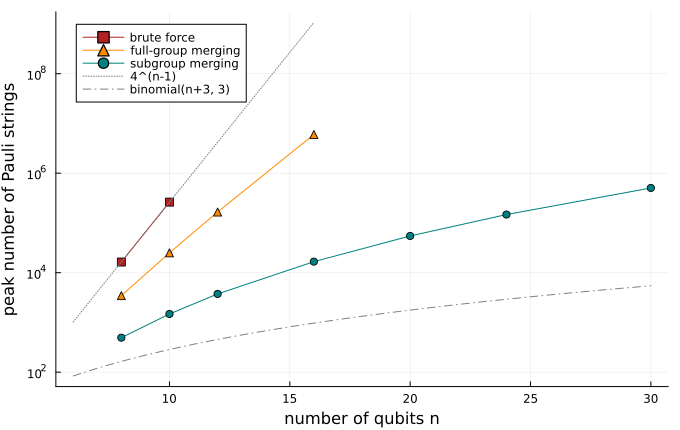

In [7]:
using Plots

xs(d) = sort(collect(keys(d)))
ys(d) = [d[n] for n in xs(d)]
plt = plot(xlabel="number of qubits n", ylabel="peak number of Pauli strings", yscale=:log10, legend=:topleft, size=(680, 430), legendfontsize=8)
plot!(plt, xs(peaks[:brute]), ys(peaks[:brute]), marker=:square, color=:firebrick, label="brute force")
plot!(plt, xs(peaks[:full]), ys(peaks[:full]), marker=:utriangle, color=:darkorange, label="full-group merging")
plot!(plt, xs(peaks[:subgroup]), ys(peaks[:subgroup]), marker=:circle, color=:teal, label="subgroup merging")
plot!(plt, 6:16, 4.0 .^ ((6:16) .- 1), linestyle=:dot, color=:gray, label="4^(n-1)")
plot!(plt, 6:30, [binomial(n + 3, 3) for n in 6:30], linestyle=:dashdot, color=:gray, label="binomial(n+3, 3)")
plt

## Translation symmetry

Any group of site permutations works the same way: `TranslationSymmetry`, `ReflectionSymmetry`, or `SiteSymmetry(nq, generators)` for an arbitrary finite group.

For a layer of 8 `ZZ` bonds on a ring, the subgroup after some bonds is the set of shifts that map the applied bonds onto themselves. In the written order $(1,2),(2,3),\dots$ the applied bonds form a segment, which no shift maps onto itself, so nothing is merged before the layer ends. The order $(1,2),(5,6),(3,4),(7,8),\dots$ gives $\mathbb{Z}_2$ after two bonds, $\mathbb{Z}_4$ after four, and so on. `symmetrypropagate` picks this order itself; reordering is allowed because the bonds commute.

In [8]:
nq = 8
T = TranslationSymmetry(nq)
bonds = [PauliRotation([:Z, :Z], [i, mod1(i + 1, nq)]) for i in 1:nq]
println("written order:")
println(subgroupschedule(T, bonds, fill(0.3, nq); order=:given))
println("\nreordered (default):")
println(subgroupschedule(T, bonds, fill(0.3, nq)))

written order:
SubgroupSchedule for 8 gates:
  after gates 1-7: TrivialSymmetry(8)
  after gate 8: TranslationSymmetry(8)

reordered (default):
SubgroupSchedule for 8 gates:
  after gate 1: TrivialSymmetry(8)
  after gate 2: SiteSymmetry(8, order 2)
  after gate 3: TrivialSymmetry(8)
  after gate 4: SiteSymmetry(8, order 4)
  after gate 5: TrivialSymmetry(8)
  after gate 6: SiteSymmetry(8, order 2)
  after gate 7: TrivialSymmetry(8)
  after gate 8: TranslationSymmetry(8)


A layer of $n$ nearest-neighbour bonds hardly grows the sum, so a chain shows no gain. We use the same all-to-all circuit as above with the coupling of the pair $(i,j)$ scaled by $1/d^3$, $d$ the distance around the ring: every layer still has $n(n-1)/2$ bonds, but only the $n$ translations (and the reflections) remain as symmetry. Times are for a second run after a warm-up; brute force and full-group merging are skipped at 14 sites, where they hold 67 million strings.

In [9]:
ringdistance(i, j, nq) = min(abs(i - j), nq - abs(i - j))
ringcircuit(nq, nlayers) = xxzcircuit(nq, nlayers; coupling=(i, j) -> 1 / ringdistance(i, j, nq)^3)

ring_peaks = Dict(method => Dict{Int,Int}() for method in (:brute, :full, :subgroup))
ring_times = Dict(method => Dict{Int,Float64}() for method in (:brute, :full, :subgroup))
ring_final = Dict{Int,Int}()
@printf("%4s %12s %12s %14s %10s %9s %9s %11s\n", "n", "peak brute", "peak full", "peak subgroup", "final", "t brute", "t full", "t subgroup")
for n in (8, 10, 12, 14)
    T_n = TranslationSymmetry(n)
    ring_n, th_n = ringcircuit(n, 2)
    warm_n, warm_th = ringcircuit(n, 1)
    obs_n = VectorPauliSum(totalx(n))
    if n <= 12
        propagate(warm_n, obs_n, warm_th; min_abs_coeff=0.0)
        ring_times[:brute][n] = @elapsed ring_peaks[:brute][n] = @peakpaulis propagate(ring_n, obs_n, th_n; min_abs_coeff=0.0)
        symmetrypropagate(T_n, warm_n, obs_n, warm_th; min_abs_coeff=0.0, subgroups=false)
        ring_times[:full][n] = @elapsed ring_peaks[:full][n] = @peakpaulis symmetrypropagate(T_n, ring_n, obs_n, th_n; min_abs_coeff=0.0, subgroups=false)
    end
    symmetrypropagate(T_n, warm_n, obs_n, warm_th; min_abs_coeff=0.0)
    ring_times[:subgroup][n] = @elapsed ring_peaks[:subgroup][n] = @peakpaulis out_n = symmetrypropagate(T_n, ring_n, obs_n, th_n; min_abs_coeff=0.0)
    ring_final[n] = length(out_n)
    @printf("%4d %12s %12s %14s %10d %9s %9s %11s\n", n, entry(ring_peaks[:brute], n), entry(ring_peaks[:full], n), entry(ring_peaks[:subgroup], n),
        ring_final[n], entry(ring_times[:brute], n), entry(ring_times[:full], n), entry(ring_times[:subgroup], n))
end

   n   peak brute    peak full  peak subgroup      final   t brute    t full  t subgroup
   8        16384        16128           6844       2048      0.01      0.01        0.01
  10       262144       261120         104020      26216      0.04      0.05        0.11
  12      4194304      4190208        1533842     349536      1.00      0.60        0.98
  14            -            -       23561734    4793492         -         -       18.81


Merging under the full group after each layer divides the final size by the group order $n$ but leaves the peak at $4^{n-1}$: the whole layer is applied before the first merge. Subgroup merging lowers the peak by a constant factor of about $2.5$ and is not faster at these sizes, because every merge sorts the whole sum. With a group of only $n$ elements the gain is bounded; the permutation group has $n!$.

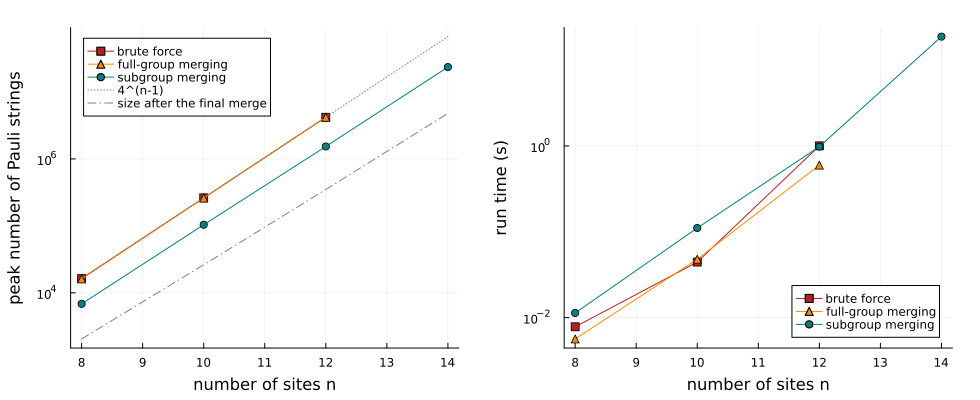

In [10]:
p1 = plot(xlabel="number of sites n", ylabel="peak number of Pauli strings", yscale=:log10, legend=:topleft, legendfontsize=8)
plot!(p1, xs(ring_peaks[:brute]), ys(ring_peaks[:brute]), marker=:square, color=:firebrick, label="brute force")
plot!(p1, xs(ring_peaks[:full]), ys(ring_peaks[:full]), marker=:utriangle, color=:darkorange, label="full-group merging")
plot!(p1, xs(ring_peaks[:subgroup]), ys(ring_peaks[:subgroup]), marker=:circle, color=:teal, label="subgroup merging")
plot!(p1, 8:14, 4.0 .^ ((8:14) .- 1), linestyle=:dot, color=:gray, label="4^(n-1)")
plot!(p1, xs(ring_final), ys(ring_final), linestyle=:dashdot, color=:gray, label="size after the final merge")
p2 = plot(xlabel="number of sites n", ylabel="run time (s)", yscale=:log10, legend=:bottomright, legendfontsize=8)
plot!(p2, xs(ring_times[:brute]), ys(ring_times[:brute]), marker=:square, color=:firebrick, label="brute force")
plot!(p2, xs(ring_times[:full]), ys(ring_times[:full]), marker=:utriangle, color=:darkorange, label="full-group merging")
plot!(p2, xs(ring_times[:subgroup]), ys(ring_times[:subgroup]), marker=:circle, color=:teal, label="subgroup merging")
plot(p1, p2, layout=(1, 2), size=(980, 400), margin=5Plots.mm)

## Two dimensions: transverse-field Ising model

`TranslationSymmetry(nx, ny)` is the translation group of a periodic `nx` x `ny` lattice, with site $(x, y)$ numbered $(y-1)\,n_x + x$ as in `rectangletopology`. The Trotter step of the nearest-neighbour TFIM, $H = -\sum_{\langle ij\rangle} Z_iZ_j - h\sum_i X_i$, is a `ZZ` layer of $2n$ bonds and an `X` layer of $n$ fields; we propagate $\sum_i Z_i$. Because a `ZZ` layer has only $2n$ gates it does not fill the sector before its merge, so here merging under the full group already lowers the peak, and subgroup merging lowers it further. Brute force and full-group merging stop at 12 sites.

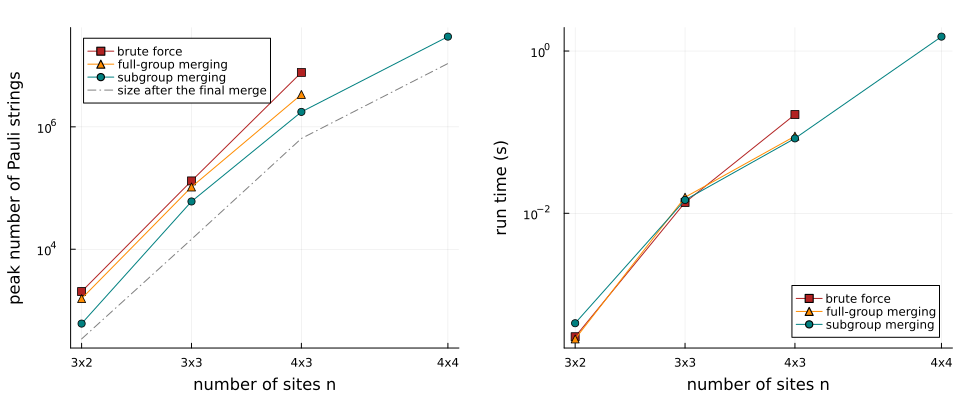

In [11]:
function tfim2d(nx, ny, nlayers; dt=0.1, h=1.0)
    circuit = tfitrottercircuit(nx * ny, nlayers; topology=rectangletopology(nx, ny; periodic=true))
    nbonds = count(gate -> length(gate.qinds) == 2, circuit) ÷ nlayers
    thetas = Float64[]
    for _ in 1:nlayers
        append!(thetas, fill(-2dt, nbonds))
        append!(thetas, fill(-2dt * h, nx * ny))
    end
    return circuit, thetas
end

function totalz(nq)
    psum = PauliSum(nq)
    for i in 1:nq
        add!(psum, :Z, i)
    end
    return psum
end

tfim_peaks = Dict(method => Dict{Int,Int}() for method in (:brute, :full, :subgroup))
tfim_times = Dict(method => Dict{Int,Float64}() for method in (:brute, :full, :subgroup))
tfim_final = Dict{Int,Int}()
for (nx, ny) in ((3, 2), (3, 3), (4, 3), (4, 4))
    n = nx * ny
    T_n = TranslationSymmetry(nx, ny)
    circ_n, th_n = tfim2d(nx, ny, 3)
    warm_n, warm_th = tfim2d(nx, ny, 1)
    obs_n = VectorPauliSum(totalz(n))
    if n <= 12
        propagate(warm_n, obs_n, warm_th; min_abs_coeff=0.0)
        tfim_times[:brute][n] = @elapsed tfim_peaks[:brute][n] = @peakpaulis propagate(circ_n, obs_n, th_n; min_abs_coeff=0.0)
        symmetrypropagate(T_n, warm_n, obs_n, warm_th; min_abs_coeff=0.0, subgroups=false)
        tfim_times[:full][n] = @elapsed tfim_peaks[:full][n] = @peakpaulis symmetrypropagate(T_n, circ_n, obs_n, th_n; min_abs_coeff=0.0, subgroups=false)
    end
    symmetrypropagate(T_n, warm_n, obs_n, warm_th; min_abs_coeff=0.0)
    tfim_times[:subgroup][n] = @elapsed tfim_peaks[:subgroup][n] = @peakpaulis out_n = symmetrypropagate(T_n, circ_n, obs_n, th_n; min_abs_coeff=0.0)
    tfim_final[n] = length(out_n)
end

p1 = plot(xlabel="number of sites n", ylabel="peak number of Pauli strings", yscale=:log10, legend=:topleft, legendfontsize=8,
    xticks=([6, 9, 12, 16], ["3x2", "3x3", "4x3", "4x4"]))
plot!(p1, xs(tfim_peaks[:brute]), ys(tfim_peaks[:brute]), marker=:square, color=:firebrick, label="brute force")
plot!(p1, xs(tfim_peaks[:full]), ys(tfim_peaks[:full]), marker=:utriangle, color=:darkorange, label="full-group merging")
plot!(p1, xs(tfim_peaks[:subgroup]), ys(tfim_peaks[:subgroup]), marker=:circle, color=:teal, label="subgroup merging")
plot!(p1, xs(tfim_final), ys(tfim_final), linestyle=:dashdot, color=:gray, label="size after the final merge")
p2 = plot(xlabel="number of sites n", ylabel="run time (s)", yscale=:log10, legend=:bottomright, legendfontsize=8,
    xticks=([6, 9, 12, 16], ["3x2", "3x3", "4x3", "4x4"]))
plot!(p2, xs(tfim_times[:brute]), ys(tfim_times[:brute]), marker=:square, color=:firebrick, label="brute force")
plot!(p2, xs(tfim_times[:full]), ys(tfim_times[:full]), marker=:utriangle, color=:darkorange, label="full-group merging")
plot!(p2, xs(tfim_times[:subgroup]), ys(tfim_times[:subgroup]), marker=:circle, color=:teal, label="subgroup merging")
plot(p1, p2, layout=(1, 2), size=(980, 400), margin=5Plots.mm)

## Notes

- Exact without truncation if every layer and the final state are $G$-invariant. `check=true` (default) verifies that each rotation layer commutes and is invariant, angles included.
- The merged sum gives correct expectation values only against $G$-invariant states.
- With `min_abs_coeff > 0`, coefficients are truncated after each merge; the result then differs from a truncated `propagate`, as for any reordering of gates.
- Use a `VectorPauliSum` for large sums, as with `propagate`.